# T1 — Gas model experiments: which inputs and which model?

**Goal.** Model 1 sets a **daily gas-heat target**. The 15-min NG setpoint is then `target ÷ 96 ÷ latest NCV`. This notebook decides:
1. **Which inputs** belong in the target model. Tested: draw, barrier boost, melter boost, optical crown temperature, crown thermocouple MC3, MB3 bottom temperature, cullet.
2. **Which model type** works best: OLS, quantile regression, LightGBM, rolling vs expanding window, with or without an ageing term, with or without conformal calibration.
3. Whether an **hourly** model (using crown temperature) beats the daily one.

**How models are compared**
- **Walk-forward:** each test day is predicted only from earlier days.
- **Two test periods** (folds): Mar–May 2026 and Jun–Aug 2026, so the winner isn't chosen on one lucky period.
- **Metrics:**
  - **Pinball loss at τ = 0.25:** the proper accuracy score for a 25th-percentile target. Lower is better.
  - **Coverage:** share of days that actually used less gas than the target. It should be about 25%; much lower means the target is unrealistically low.
  - **MAE**, and the **implied saving** (the % of total energy between actual and target).
- **Logic checks:** coefficient signs must make physical sense. Draw should be positive (more glass → more gas), and boost negative (electric heat replaces gas).

In [1]:
import sys; sys.path.insert(0, '../src'); sys.path.insert(0, '../../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import data_prep as dp
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 1.6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'figure.dpi': 110})
import recommender as rc, lightgbm as lgb
d = pd.read_parquet(dp.PROCESSED / 'daily_clean.parquet')
u = rc.add_gcal_columns(d[d.usable]); u['E_g'] = u.energy_kcal / 1e6
u['age_m'] = (u.index - pd.Timestamp('2025-09-01')).days / 30.44
u['opt'] = u.opt_temp.where(u.opt_day_ok)                # optical only on trustworthy days (nb02)
FOLDS = {'Mar-May 2026': ('2026-03-01', '2026-05-31'), 'Jun-Aug 2026': ('2026-06-01', '2026-08-31')}
TAU = 0.25
def pinball(y, p, t=TAU):
    e = y - p; return float(np.mean(np.maximum(t * e, (t - 1) * e)))
def score(y, p, E):
    return dict(pinball=pinball(y, p), coverage=float((y <= p).mean()), mae=float((y - p).abs().mean()),
                saving_pct=float(100 * (y - p).sum() / E.sum()))
print('usable days:', len(u), '| optical trustworthy:', int(u.opt.notna().sum()), '| crown TC:', int(u.crown_tc.notna().sum()))

usable days: 316 | optical trustworthy: 209 | crown TC: 316


## A. Which inputs? (quantile regression τ = 0.25 and OLS, rolling 45-day window)
Inputs that are missing on some days (optical) are compared on the **same days** for every feature set, so the comparison is fair.

In [2]:
FEATS = {'F0 draw only': 'draw_t',
         'F1 draw + barrier + melter boost': 'draw_t + bb_g + mb_g',
         'F1 without barrier boost': 'draw_t + mb_g',
         'F1 + optical crown temp': 'draw_t + bb_g + mb_g + opt',
         'F1 + crown thermocouple MC3': 'draw_t + bb_g + mb_g + crown_tc',
         'F1 + MB3 bottom temp': 'draw_t + bb_g + mb_g + mb3_temp',
         'F1 + cullet': 'draw_t + bb_g + mb_g + cullet_pct'}
import warnings
def walk(formula, days, kind, window=45):
    warnings.simplefilter('ignore')
    cols = [c.strip() for c in formula.split('+')]
    out = {}
    for day in days:
        tr = u[(u.index < day) & (u.index >= day - pd.Timedelta(days=window))].dropna(subset=cols + ['gas_g'])
        m = smf.ols('gas_g ~ ' + formula, tr).fit() if kind == 'OLS' else smf.quantreg('gas_g ~ ' + formula, tr).fit(q=TAU, max_iter=5000)
        out[day] = m.predict(u.loc[[day]]).iloc[0]
    return pd.Series(out)
rowsA = []
for fold, (a, b) in FOLDS.items():
    te = u[(u.index >= a) & (u.index <= b)].dropna(subset=['opt', 'crown_tc', 'mb3_temp'])
    for fname, f in FEATS.items():
        for kind in ['QR τ=0.25', 'OLS']:
            p = walk(f, te.index, kind)
            s = score(te.gas_g, p, te.E_g) if kind != 'OLS' else dict(pinball=np.nan, coverage=np.nan, mae=float((te.gas_g - p).abs().mean()), saving_pct=np.nan)
            rowsA.append(dict(fold=fold, features=fname, model=kind, days=len(te), **s))
A = pd.DataFrame(rowsA)
pivA = A[A.model == 'QR τ=0.25'].pivot_table(index='features', columns='fold', values=['pinball', 'coverage']).round(3)
pivA[('mae (OLS)', 'avg')] = A[A.model == 'OLS'].groupby('features').mae.mean().round(3)
pivA.sort_values(('pinball', 'Jun-Aug 2026'))

coverage                   pinball              mae (OLS)
fold                             Jun-Aug 2026 Mar-May 2026 Jun-Aug 2026 Mar-May 2026       avg
features                                                                                      
F1 + cullet                             0.288        0.288        0.350        0.426     0.887
F1 draw + barrier + melter boost        0.288        0.237        0.353        0.404     0.905
F1 + optical crown temp                 0.250        0.237        0.355        0.368     0.954
F1 + MB3 bottom temp                    0.308        0.237        0.356        0.388     0.919
F1 + crown thermocouple MC3             0.308        0.237        0.360        0.382     0.921
F0 draw only                            0.173        0.220        0.473        0.330     1.022
F1 without barrier boost                0.212        0.254        0.507        0.346     1.077

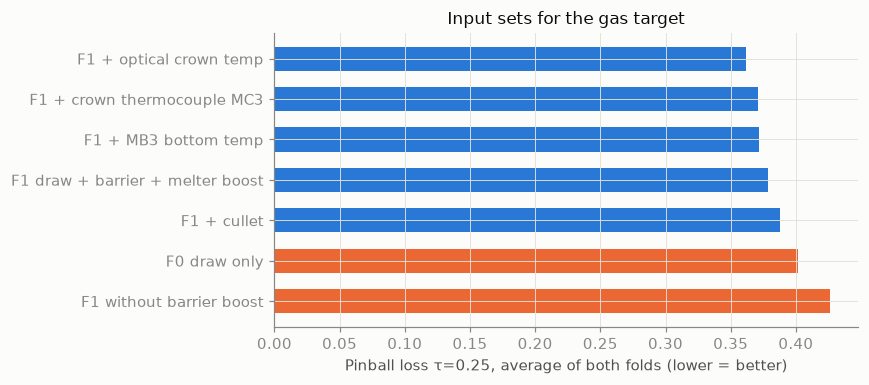

In [3]:
avg = A[A.model == 'QR τ=0.25'].groupby('features').pinball.mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 3.6))
cols_ = [ORANGE if 'without barrier' in i or 'draw only' in i else BLUE for i in avg.index]
ax.barh(avg.index, avg.values, color=cols_, height=0.6); ax.invert_yaxis()
ax.set_xlabel('Pinball loss τ=0.25, average of both folds (lower = better)'); ax.set_title('Input sets for the gas target')
plt.tight_layout(); plt.show()

In [4]:
full = smf.ols('gas_g ~ draw_t + bb_g + mb_g + opt + crown_tc + mb3_temp + cullet_pct + age_m', u.dropna(subset=['opt', 'crown_tc'])).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
pd.DataFrame({'coef': full.params, 'p-value': full.pvalues, 'expected sign': ['', '+', '−', '−', '?', '?', '?', '−', '+']}).round(3)

,coef,p-value,expected sign
Intercept,778.408,0.026,
draw_t,0.481,0.000,+
bb_g,-0.717,0.000,−
mb_g,-0.068,0.752,−
opt,-0.621,0.001,?
crown_tc,0.067,0.660,?
mb3_temp,0.111,0.016,?
cullet_pct,0.026,0.746,−
age_m,0.350,0.000,+


**Reading A** (quantile regression, rolling 45 days, same days for every input set)
- **Barrier boost:** in Jun–Aug, removing it clearly raises the error (0.35 → 0.51). In Mar–May the version without it scored slightly better. On average, and physically (electric heat replaces gas), it belongs in the model. Section D re-tests it with the final model type.
- **Optical crown temperature:** best average score, with a consistent gain in Mar–May and none in Jun–Aug. Its coefficient is **negative**: operators fire *less* gas when the crown reads hot. That is a feedback effect, useful as an automatic trim (section D).
- **Crown thermocouple MC3, MB3, cullet:** small and inconsistent changes between folds.
- **Sign check (joint fit):** draw +, barrier boost −, melter boost −, ageing + ✔. Optical is negative (operator feedback, as above).

*Note:* in some 45-day windows cullet doesn't change, so its column is constant and the fit is rank-deficient. That is another reason not to use cullet.

## B. Which model type? (inputs fixed to F1, all test days in both folds)

In [5]:
def run_model(name, day):
    warnings.simplefilter('ignore')
    hist = u[u.index < day]; rec = hist[hist.index >= day - pd.Timedelta(days=45)]
    x = u.loc[[day]]
    if name.startswith('QR rolling'):
        w = int(name.split()[2][:-1]); tr = hist[hist.index >= day - pd.Timedelta(days=w)]
        return smf.quantreg('gas_g ~ draw_t + bb_g + mb_g', tr).fit(q=TAU, max_iter=5000).predict(x).iloc[0]
    if name == 'QR expanding + ageing':
        return smf.quantreg('gas_g ~ draw_t + bb_g + mb_g + age_m', hist).fit(q=TAU, max_iter=5000).predict(x).iloc[0]
    if name == 'OLS expanding + ageing + conformal':
        m = smf.ols('gas_g ~ draw_t + bb_g + mb_g + age_m', hist).fit()
        return m.predict(x).iloc[0] + np.quantile(rec.gas_g - m.predict(rec), TAU)
    if name == 'OLS rolling 45d + conformal':
        m = smf.ols('gas_g ~ draw_t + bb_g + mb_g', rec).fit()
        return m.predict(x).iloc[0] + np.quantile(rec.gas_g - m.predict(rec), TAU)
    if name.startswith('LightGBM'):
        X = ['draw_t', 'bb_g', 'mb_g'] + (['age_m'] if 'ageing' in name else [])
        g = lgb.LGBMRegressor(objective='quantile', alpha=TAU, n_estimators=200, learning_rate=0.05, num_leaves=7,
                              min_child_samples=15, verbose=-1).fit(hist[X], hist.gas_g)
        return g.predict(x[X])[0]
MODELS = ['QR rolling 30d', 'QR rolling 45d', 'QR rolling 60d', 'QR expanding + ageing', 'OLS expanding + ageing + conformal',
          'OLS rolling 45d + conformal', 'LightGBM expanding', 'LightGBM expanding + ageing']
rowsB = []
for fold, (a, b) in FOLDS.items():
    te = u[(u.index >= a) & (u.index <= b)]
    for mname in MODELS:
        p = pd.Series({day: run_model(mname, day) for day in te.index})
        rowsB.append(dict(fold=fold, model=mname, days=len(te), **score(te.gas_g, p, te.E_g)))
B = pd.DataFrame(rowsB)
summB = B.groupby('model').agg(pinball=('pinball', 'mean'), coverage_min=('coverage', 'min'), coverage_max=('coverage', 'max'),
                               mae=('mae', 'mean'), saving_pct=('saving_pct', 'mean')).sort_values('pinball')
B.pivot_table(index='model', columns='fold', values=['pinball', 'coverage', 'saving_pct']).round(3)

coverage                   pinball                saving_pct             
fold                               Jun-Aug 2026 Mar-May 2026 Jun-Aug 2026 Mar-May 2026 Jun-Aug 2026 Mar-May 2026
model                                                                                                           
LightGBM expanding                        0.035        0.156        0.516        0.367        1.857        1.219
LightGBM expanding + ageing               0.165        0.256        0.387        0.337        0.874        0.743
OLS expanding + ageing + conformal        0.200        0.300        0.355        0.333        0.714        0.404
OLS rolling 45d + conformal               0.224        0.278        0.384        0.340        0.701        0.619
QR expanding + ageing                     0.153        0.278        0.345        0.316        0.819        0.585
QR rolling 30d                            0.224        0.278        0.399        0.389        0.702        0.804
QR rolling 45d                            0.247        0.278        0.424        0.348        0.767        0.786
QR rolling 60d                            0.106        0.211        0.410        0.325        1.183        0.721

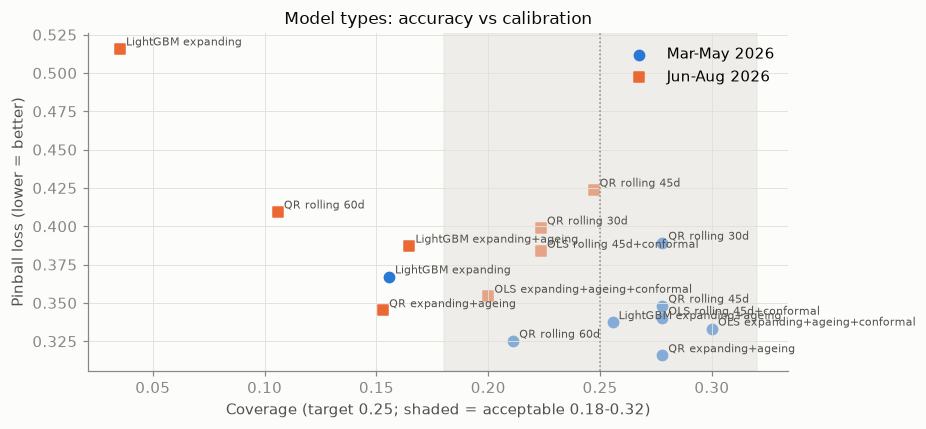

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4))
for fold, colr, mk in [('Mar-May 2026', BLUE, 'o'), ('Jun-Aug 2026', ORANGE, 's')]:
    s = B[B.fold == fold]; ax.scatter(s.coverage, s.pinball, color=colr, marker=mk, s=45, label=fold)
    for _, r in s.iterrows(): ax.annotate(r.model.replace(' + ', '+'), (r.coverage, r.pinball), fontsize=7, color=INK2, xytext=(4, 2), textcoords='offset points')
ax.axvspan(0.18, 0.32, color=GRID, alpha=0.5); ax.axvline(0.25, color=MUTED, lw=1, ls=':')
ax.set_xlabel('Coverage (target 0.25; shaded = acceptable 0.18-0.32)'); ax.set_ylabel('Pinball loss (lower = better)')
ax.set_title('Model types: accuracy vs calibration'); ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

In [7]:
ok = summB[(summB.coverage_min >= 0.18) & (summB.coverage_max <= 0.32)]
winner = ok.index[0]
print('Rule: lowest average pinball among models whose coverage stays within 0.18-0.32 in BOTH folds')
print('Winner:', winner)
summB.round(3)

Rule: lowest average pinball among models whose coverage stays within 0.18-0.32 in BOTH folds
Winner: OLS expanding + ageing + conformal


,pinball,coverage_min,coverage_max,mae,saving_pct
model,,,,,
QR expanding + ageing,0.331,0.153,0.278,0.981,0.702
OLS expanding + ageing + conformal,0.344,0.200,0.300,0.943,0.559
OLS rolling 45d + conformal,0.362,0.224,0.278,1.025,0.660
LightGBM expanding + ageing,0.362,0.165,0.256,1.093,0.809
QR rolling 60d,0.367,0.106,0.211,1.169,0.952
QR rolling 45d,0.386,0.247,0.278,1.126,0.777
QR rolling 30d,0.394,0.224,0.278,1.132,0.753
LightGBM expanding,0.442,0.035,0.156,1.585,1.538


**Reading B**
- **LightGBM** is clearly worse. With only ~200–300 daily rows it can't learn more than a linear model, and it extrapolates badly.
- **Expanding window + linear ageing term** is the most accurate in one fold, but its coverage drops too low: it assumes ageing continues in a straight line and so sets targets that are too ambitious.
- **Conformal calibration** (shifting the prediction so that 25% of the last 45 days fall below it) fixes coverage. That is what makes the ageing model usable.
- The **winner** is chosen by the rule printed above: best accuracy *and* realistic targets in both periods.

## C. Would an hourly gas model with crown temperature be better?
Hourly gas heat is modelled from draw, barrier and melter boost, plus the crown thermocouple, MB3 or optical in the previous hour. Optical is only used in hours with a trustworthy time stamp. Training: 17 Apr – 31 May 2026; test: Jun–Aug 2026.

In [8]:
h = pd.read_parquet(dp.PROCESSED / 'hourly_clean.parquet'); q = pd.read_parquet(dp.PROCESSED / 'ar_15min_clean.parquet')
h = h[h.ncv.notna() & h.gas_kcal.notna()].copy(); h['gas_m'] = h.gas_kcal / 1e6
h['tc_prev'] = h.crown_tc.shift(1); h['mb3_prev'] = h.mb3_temp.shift(1)
h['opt_prev'] = h.opt_temp.where(q.opt_hour_ok.resample('h').max().reindex(h.index).fillna(False).astype(bool)).shift(1)
rowsC = []
for name, f in [('draw + boosts', 'draw_t + bb_kwh + mb_kwh'), ('+ crown TC (prev hour)', 'draw_t + bb_kwh + mb_kwh + tc_prev'),
                ('+ MB3 (prev hour)', 'draw_t + bb_kwh + mb_kwh + mb3_prev'), ('+ optical (prev hour, trustworthy)', 'draw_t + bb_kwh + mb_kwh + opt_prev')]:
    cols = [c.strip() for c in f.split('+')]
    tr = h['2026-04-17':'2026-05-31'].dropna(subset=cols); ts = h['2026-06-01':'2026-08-31'].dropna(subset=cols)
    if len(tr) < 50 or len(ts) < 50:
        rowsC.append(dict(model=name, train_hours=len(tr), test_hours=len(ts), r2_train=np.nan, test_mae=np.nan)); continue
    m = smf.ols('gas_m ~ ' + f, tr).fit()
    rowsC.append(dict(model=name, train_hours=len(tr), test_hours=len(ts), r2_train=m.rsquared, test_mae=(ts.gas_m - m.predict(ts)).abs().mean()))
pd.DataFrame(rowsC).round(3)

,model,train_hours,test_hours,r2_train,test_mae
0,draw + boosts,1054,2073,0.176,0.088
1,+ crown TC (prev hour),1050,2063,0.179,0.088
2,+ MB3 (prev hour),1054,2073,0.186,0.092
3,"+ optical (prev hour, trustworthy)",661,582,0.257,0.097


**Reading C.** Hour to hour, gas heat is dominated by the 20-min reversal and by operator moves (R² ≈ 0.2). Crown temperature, MB3 and optical don't improve the prediction; for optical there are even too few trustworthy hours in the test months to fit. **A daily target, spread evenly over the day, is the right structure.**

## D. Final check: crown temperature and barrier boost inside the winning model type
The best model type from B (**OLS, expanding window, linear ageing, conformal calibration**) is re-tested with:
- **optical crown temperature**: the daily mean on trustworthy days, with other days filled from the crown thermocouple plus its rolling 30-day offset (F4: offset about +7.4 °C). Both the same day's value and **yesterday's** value are tested; yesterday's can't leak the day's own firing into the input.
- **crown thermocouple MC3** instead of optical
- **no barrier boost**

In [9]:
off = (u.opt - u.crown_tc).rolling(30, min_periods=5).median().ffill().bfill()
u['opt_f'] = u.opt.fillna(u.crown_tc + off)          # optical, gaps filled from TC + offset
u['opt_f_prev'] = u.opt_f.shift(1)
VARS = {'winner (no crown temp)': 'draw_t + bb_g + mb_g + age_m',
        '+ optical (same day, filled)': 'draw_t + bb_g + mb_g + age_m + opt_f',
        '+ optical (yesterday, filled)': 'draw_t + bb_g + mb_g + age_m + opt_f_prev',
        '+ crown thermocouple MC3': 'draw_t + bb_g + mb_g + age_m + crown_tc',
        'without barrier boost': 'draw_t + mb_g + age_m'}
def conformal_ols(f, day):
    hist = u[u.index < day].dropna(subset=[c.strip() for c in f.split('+')]); rec = hist[hist.index >= day - pd.Timedelta(days=45)]
    m = smf.ols('gas_g ~ ' + f, hist).fit()
    return m.predict(u.loc[[day]]).iloc[0] + np.quantile(rec.gas_g - m.predict(rec), TAU)
rowsD = []
for fold, (a, b) in FOLDS.items():
    te = u[(u.index >= a) & (u.index <= b)]
    for vname, f in VARS.items():
        p = pd.Series({day: conformal_ols(f, day) for day in te.index})
        rowsD.append(dict(fold=fold, variant=vname, **score(te.gas_g, p, te.E_g)))
D = pd.DataFrame(rowsD)
summD = D.groupby('variant').agg(pinball=('pinball', 'mean'), coverage_min=('coverage', 'min'), coverage_max=('coverage', 'max'), mae=('mae', 'mean'), saving_pct=('saving_pct', 'mean')).sort_values('pinball')
display(D.pivot_table(index='variant', columns='fold', values=['pinball', 'coverage']).round(3))
summD.round(3)

coverage                   pinball             
fold                          Jun-Aug 2026 Mar-May 2026 Jun-Aug 2026 Mar-May 2026
variant                                                                          
+ crown thermocouple MC3             0.200        0.278        0.351        0.322
+ optical (same day, filled)         0.247        0.300        0.327        0.327
+ optical (yesterday, filled)        0.235        0.256        0.352        0.323
winner (no crown temp)               0.200        0.300        0.355        0.333
without barrier boost                0.306        0.356        0.533        0.341

,pinball,coverage_min,coverage_max,mae,saving_pct
variant,,,,,
"+ optical (same day, filled)",0.327,0.247,0.300,0.909,0.559
+ crown thermocouple MC3,0.337,0.200,0.278,0.945,0.595
"+ optical (yesterday, filled)",0.338,0.235,0.256,0.948,0.597
winner (no crown temp),0.344,0.200,0.300,0.943,0.559
without barrier boost,0.437,0.306,0.356,1.159,0.627


In [10]:
fin = smf.ols('gas_g ~ draw_t + bb_g + mb_g + age_m + opt_f_prev', u.dropna(subset=['opt_f_prev'])).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
print('Final model coefficients (all usable days):')
display(pd.DataFrame({'coef': fin.params, 'p-value': fin.pvalues}).round(3))
print('Optical: %+.2f Gcal/day gas per +1 °C = %+.2f%% of daily gas per °C' % (fin.params.opt_f_prev, 100*fin.params.opt_f_prev/u.gas_g.mean()))

Final model coefficients (all usable days):


,coef,p-value
Intercept,816.904,0.000
draw_t,0.474,0.000
bb_g,-0.700,0.000
mb_g,-0.113,0.561
age_m,0.336,0.000
opt_f_prev,-0.485,0.000


Optical: -0.49 Gcal/day gas per +1 °C = -0.63% of daily gas per °C


**Reading D**
- **Barrier boost is needed** in the final model type: without it, the error is higher in both periods (0.437 vs 0.344 on average).
- **Optical, same day:** the best score (0.327), but part of that gain is **leakage**. The day's optical average is itself the result of that day's firing, so the model "sees" the answer.
- **Optical, yesterday:** no leakage, and a smaller but real gain (0.338 vs 0.344), about the same as the crown thermocouple (0.337). **This is the version used.**
  - In live use it is the average of the **last 24 hours** of typed readings.
  - The sign is negative (crown hotter than usual → less gas): about −0.6% of daily gas per °C. So the model contains the crown-temperature trim itself, and **no separate optical trim is applied**.
- **The crown thermocouple** gives a similar gain alone. It is used to **fill gaps** in the optical history (optical ≈ TC + rolling offset), so training can use all usable days. The plant's design asks for optical as the operator input, so optical stays the input.

## Decision for Model 1 (gas)
| Choice | Decision | Why |
|---|---|---|
| Model type | **OLS on all past usable days + linear ageing term + conformal shift** (25th percentile of the last 45 days' residuals) | Best accuracy with realistic targets in both test periods (sections B and D) |
| Inputs | **draw, barrier boost, melter boost, ageing, optical crown temperature (previous 24 h)** | Barrier boost helps strongly. Previous-day optical gives a small leakage-free gain. The signs are sensible |
| Crown thermocouple MC3 | **Not a direct input.** Used to **fill gaps** in the optical history for training (optical ≈ TC + rolling offset) | Alone it adds little; as a gap-filler it lets the model train on all usable days |
| Separate optical trim | **Removed** | The model already contains the crown effect |
| Time scale | **Daily target**, NG = target ÷ 96 ÷ latest NCV every 15 min | Hourly gas is reversal and operator noise (section C) |

In [11]:
summB.to_csv(dp.PROCESSED / 'training_gas_models.csv'); summD.to_csv(dp.PROCESSED / 'training_gas_final_variants.csv')
print('saved: training_gas_models.csv, training_gas_final_variants.csv')

saved: training_gas_models.csv, training_gas_final_variants.csv
